In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

--------
## Tycho-2

In [3]:
tycho2 = Table.read('/Users/rongpu/Documents/Data/useful/Tycho-2.fits')
tycho2.rename_columns(['RAmdeg', 'DEmdeg'], ['RA', 'DEC'])
mask = np.isfinite(tycho2['RA']) & np.isfinite(tycho2['DEC'])
print(np.sum(~mask), np.sum(~mask)/len(mask))
tycho2 = tycho2[mask]

109445 0.043090058596495236


In [4]:
tycho2[:1]

RA,DEC,BTmag,VTmag
deg,deg,mag,mag
float64,float64,float32,float32
2.31750494,2.23184345,12.146,12.146


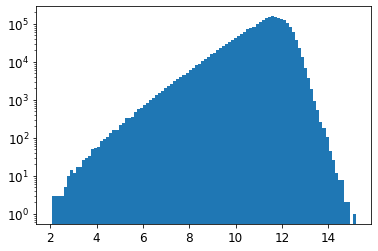

In [5]:
plt.hist(tycho2['VTmag'], 100, log=True);

270


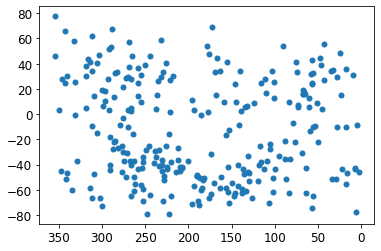

In [6]:
mask = tycho2['VTmag']<4
print(np.sum(mask))
plt.plot(tycho2['RA'][mask], tycho2['DEC'][mask], '.', ms=10, alpha=1)
plt.gca().invert_xaxis()
plt.show()

In [7]:
# t = Table()
# t['RA'] = tycho2['RA'][mask]
# t['DEC'] = tycho2['DEC'][mask]
# t.write('/Users/rongpu/Downloads/visual_inspection.fits', overwrite=True)

The Tycho-2 catalog is incomplete for V<~3.

-------
## Hipparcos

In [8]:
cat = Table.read('/Users/rongpu/Documents/Data/useful/Hipparcos_Vmag_less_than_4.fit')
print(len(cat))
cat.rename_columns(['RAICRS', 'DEICRS'], ['RA', 'DEC'])
cat[:1]

516


HIP,Vmag,RA,DEC,B-V,Notes,_RA_icrs,_DE_icrs,recno
,mag,deg,deg,mag,,deg,deg,
int32,float32,float64,float64,float32,bytes1,float64,float64,int32
677,2.07,2.09653333,29.09082805,-0.038,P,2.09691071,29.09043199,677


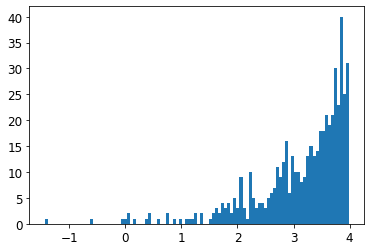

In [9]:
plt.hist(cat['Vmag'], 100);

516


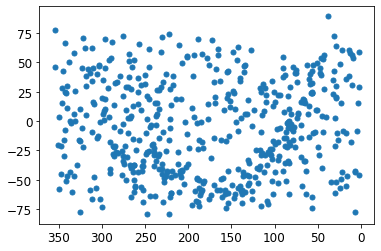

In [10]:
mask = cat['Vmag']<4
print(np.sum(mask))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=10, alpha=1)
plt.gca().invert_xaxis()
plt.show()

In [11]:
# t = Table()
# t['RA'] = cat['RA'][mask]
# t['DEC'] = cat['DEC'][mask]
# t.write('/Users/rongpu/Downloads/visual_inspection_h.fits', overwrite=True)

In [12]:
from astropy.coordinates import SkyCoord
c = SkyCoord(cat['RA'], cat['DEC'], unit='deg').galactic
l, b = c.l.to_value('deg'), c.b.to_value('deg')

mask = np.abs(b)>13
print(np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

177 0.3430232558139535


339


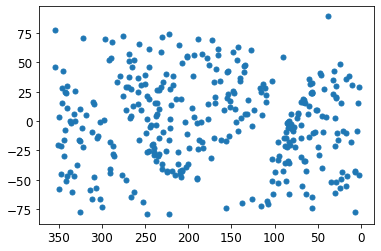

In [13]:
mask = cat['Vmag']<4
print(np.sum(mask))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=10, alpha=1)
plt.gca().invert_xaxis()
plt.show()

103


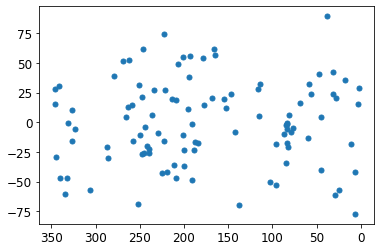

In [14]:
mask = cat['Vmag']<3
print(np.sum(mask))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=10, alpha=1)
plt.gca().invert_xaxis()
plt.show()

In [15]:
# idx = np.where(mask)[0]
# print(len(idx))
# if len(idx)>200:
#     idx = np.random.choice(idx, size=200, replace=False)
# t = Table()
# t['RA'] = cat['RA'][idx]
# t['DEC'] = cat['DEC'][idx]
# t.write('/Users/rongpu/Downloads/visual_inspection.txt', format='ascii.no_header', overwrite=True)

In [16]:
# t = Table()
# t['RA'] = cat['RA'][mask]
# t['DEC'] = cat['DEC'][mask]
# t.write('/Users/rongpu/Downloads/visual_inspection_h.fits', overwrite=True)

In [17]:
# mask &= cat['Vmag']<3
# mask = (cat['RA']>194.0057-0.1) & (cat['RA']<194.0057+0.1)
# cat[mask]

------

In [45]:
# Bright stars with insufficient masking in DR9
ra_list, dec_list = np.array([
[84.91224975, -34.07404941],
[141.89688260, -8.65868335],
[178.45725536, 53.69473296],
[193.50680410, 55.95984301],
[194.00767051, 38.31824617],
[247.55525697, 21.48964850]
]).T

In [46]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))

from match_coord import match_coord
idx1, idx2, d2d, d_ra, d_dec = match_coord(cat['RA'], cat['DEC'], ra_list, dec_list, search_radius=1., plot_q=False)

Doubly matched objects = 0
Final matched objects = 6


In [47]:
cat[idx1]

HIP,Vmag,RA,DEC,B-V,Notes,_RA_icrs,_DE_icrs,recno
,mag,deg,deg,mag,,deg,deg,
int32,float32,float64,float64,float32,bytes1,float64,float64,int32
26634,2.65,84.91224975,-34.07404941,-0.120,,84.91224946,-34.07410786,26616
46390,1.99,141.89688260,-8.65868335,1.440,,141.89684698,-8.65860253,46358
58001,2.41,178.45725536,53.69473296,0.044,,178.45769772,53.69476008,57956
62956,1.76,193.50680410,55.95984301,-0.022,,193.50728928,55.95982116,62903
63125,2.89,194.00767051,38.31824617,-0.115,P,194.00694736,38.31837980,63072
80816,2.78,247.55525697,21.48964850,0.947,D,247.55499986,21.48961328,80751


270


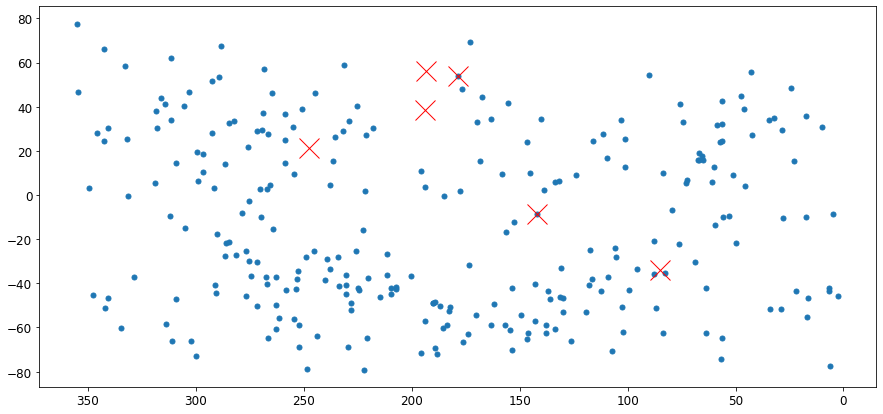

In [41]:
mask = tycho2['VTmag']<4
print(np.sum(mask))
plt.figure(figsize=(15, 7))
plt.plot(tycho2['RA'][mask], tycho2['DEC'][mask], '.', ms=10, alpha=1)
plt.plot(ra_list, dec_list, 'rx', ms=20, alpha=1)
plt.gca().invert_xaxis()
plt.show()

270


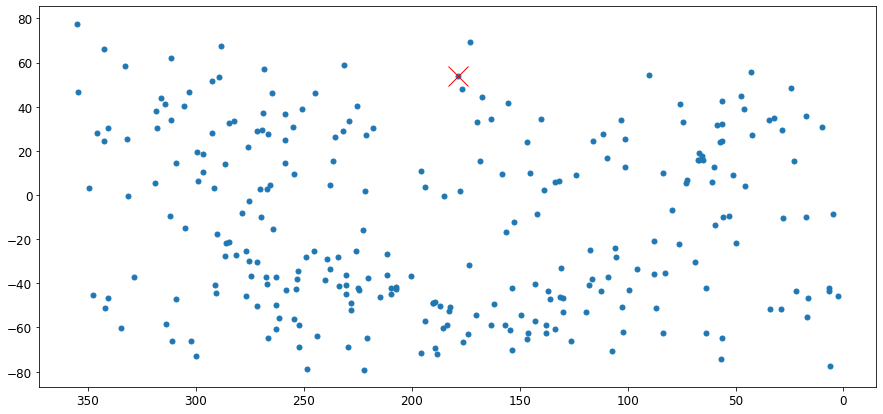

In [33]:
mask = tycho2['VTmag']<4
print(np.sum(mask))
plt.figure(figsize=(15, 7))
plt.plot(tycho2['RA'][mask], tycho2['DEC'][mask], '.', ms=10, alpha=1)
plt.plot((ra_list)[[0]], dec_list[[0]], 'rx', ms=20, alpha=1)
plt.gca().invert_xaxis()
plt.show()

In [35]:
ra, dec = ra_list[0], dec_list[0]
print(ra, dec)
ramin, ramax, decmin, decmax = ra - 10/3600, ra + 10/3600, dec - 5/3600, dec + 5/3600, 

mask = (tycho2['RA']>ramin) & (tycho2['RA']<ramax) & (tycho2['DEC']>decmin) & (tycho2['DEC']<decmax)
mask &= tycho2['VTmag']<3
tycho2[mask]

178.45725536 53.69473296


RA,DEC,BTmag,VTmag
deg,deg,mag,mag
float64,float64,float32,float32
178.45768181,53.69475740,2.456,2.399


1171


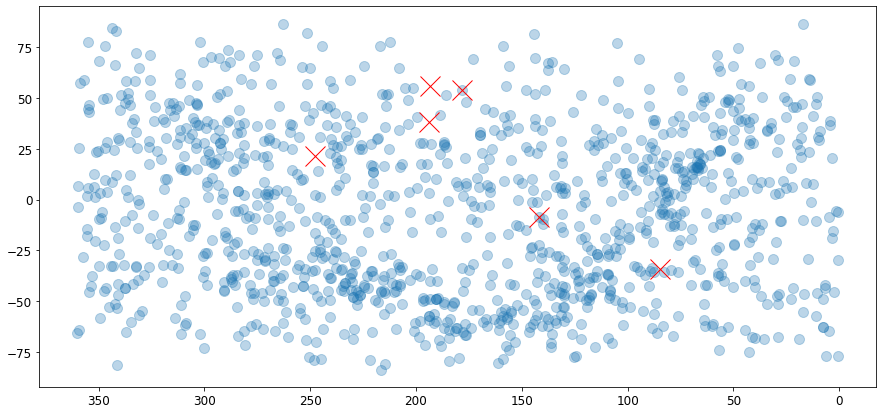

In [36]:
mask = tycho2['VTmag']<5
print(np.sum(mask))
plt.figure(figsize=(15, 7))
plt.plot(tycho2['RA'][mask], tycho2['DEC'][mask], 'o', ms=10, alpha=0.3)
plt.plot(ra_list, dec_list, 'rx', ms=20, alpha=1)
plt.gca().invert_xaxis()
plt.show()